In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

In [2]:
df = pd.read_csv("../../data/processed/delays/delays_processed.csv")

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,0.0,0.0,0.0,0.0,0.0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,0.0,0.0,0.0,0.0,0.0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,0.0,0.0,0.0,0.0,0.0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
FL_DATE,3000000,2021-05-07 18:03:59.616002048,2019-01-01 00:00:00,2019-12-28 00:00:00,2021-06-28 00:00:00,2022-08-02 00:00:00,2023-08-31 00:00:00,NaN
DOT_CODE,3000000.0,19976.294095,19393.0,19790.0,19930.0,20368.0,20452.0,377.284619
FL_NUMBER,3000000.0,2511.535519,1.0,1051.0,2152.0,3797.0,9562.0,1747.25804
CRS_DEP_TIME,3000000.0,1327.061984,1.0,915.0,1320.0,1730.0,2359.0,485.878854
DEP_TIME,2922385.0,1329.775913,1.0,916.0,1323.0,1739.0,2400.0,499.310052
DEP_DELAY,2922356.0,10.123326,-90.0,-6.0,-2.0,6.0,2966.0,49.251835
TAXI_OUT,2921194.0,16.643046,1.0,11.0,14.0,19.0,184.0,9.192901
WHEELS_OFF,2921194.0,1352.360989,1.0,931.0,1336.0,1752.0,2400.0,500.872687
WHEELS_ON,2920056.0,1462.499569,1.0,1049.0,1501.0,1908.0,2400.0,527.236818
TAXI_IN,2920056.0,7.678982,1.0,4.0,6.0,9.0,249.0,6.269639


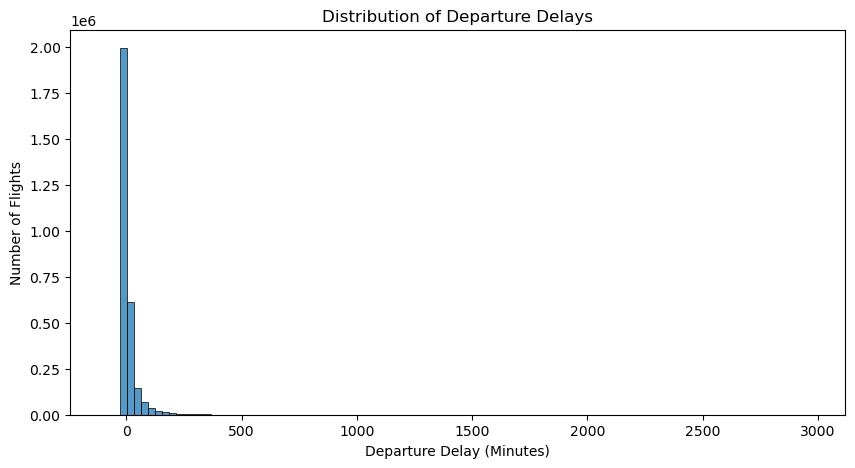

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(df["DEP_DELAY"], bins=100)

plt.title("Distribution of Departure Delays")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

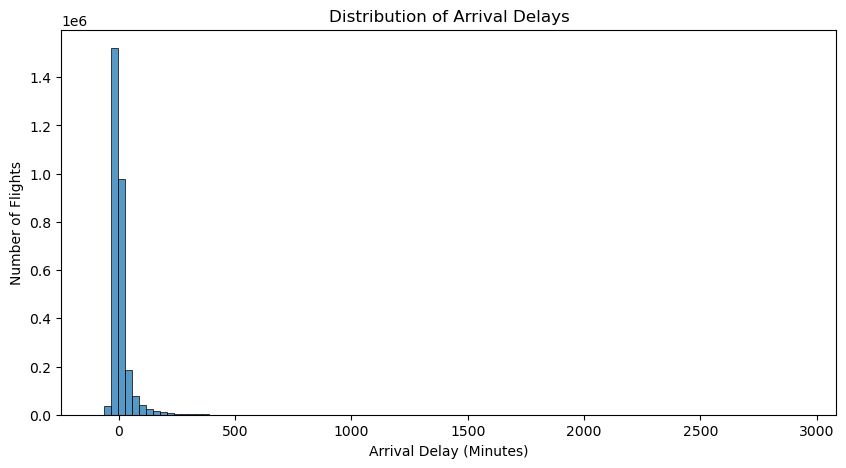

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(df["ARR_DELAY"], bins=100)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

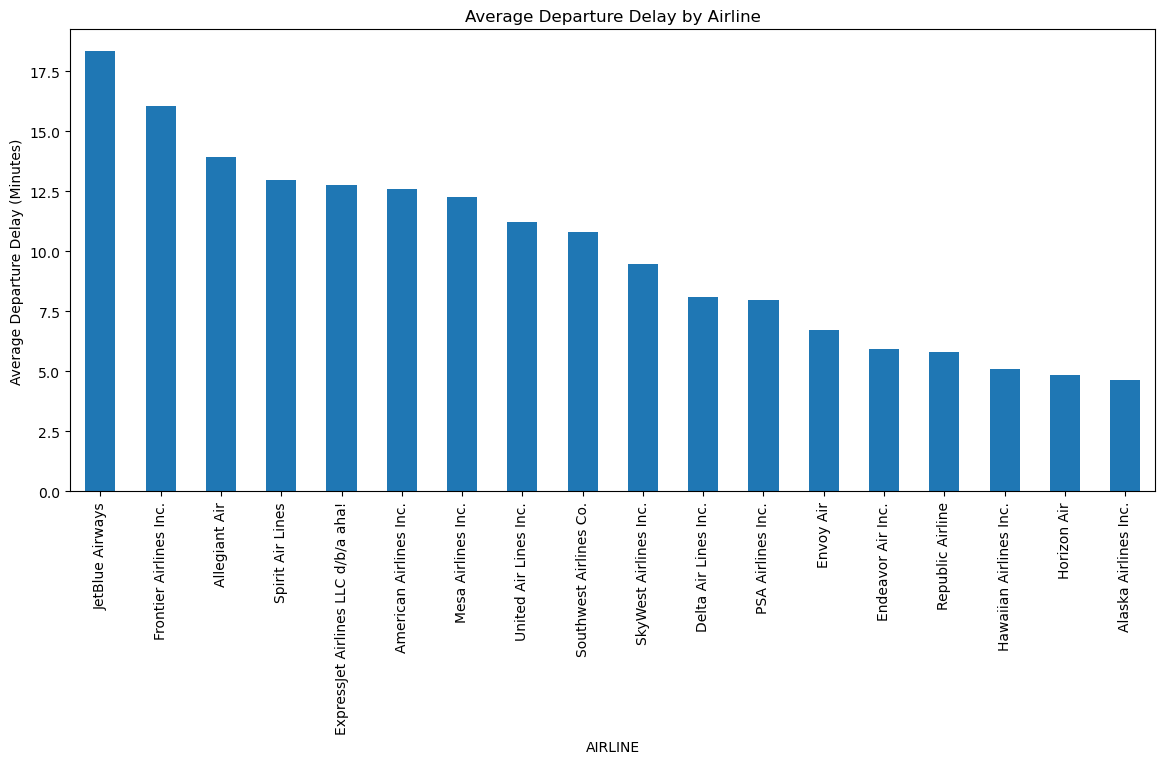

In [6]:
airline_delay = (
    df.groupby("AIRLINE")["DEP_DELAY"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))

airline_delay.plot(kind="bar")

plt.ylabel("Average Departure Delay (Minutes)")
plt.title("Average Departure Delay by Airline")

plt.show()

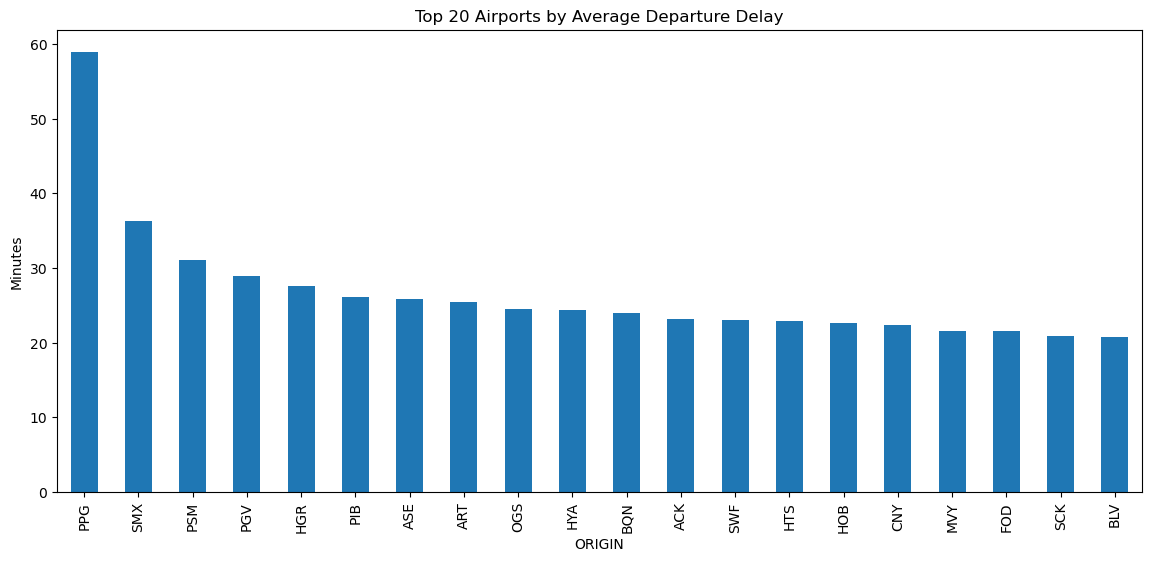

In [7]:
origin_delay = (
    df.groupby("ORIGIN")["DEP_DELAY"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

origin_delay.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Top 20 Airports by Average Departure Delay")
plt.ylabel("Minutes")

plt.show()

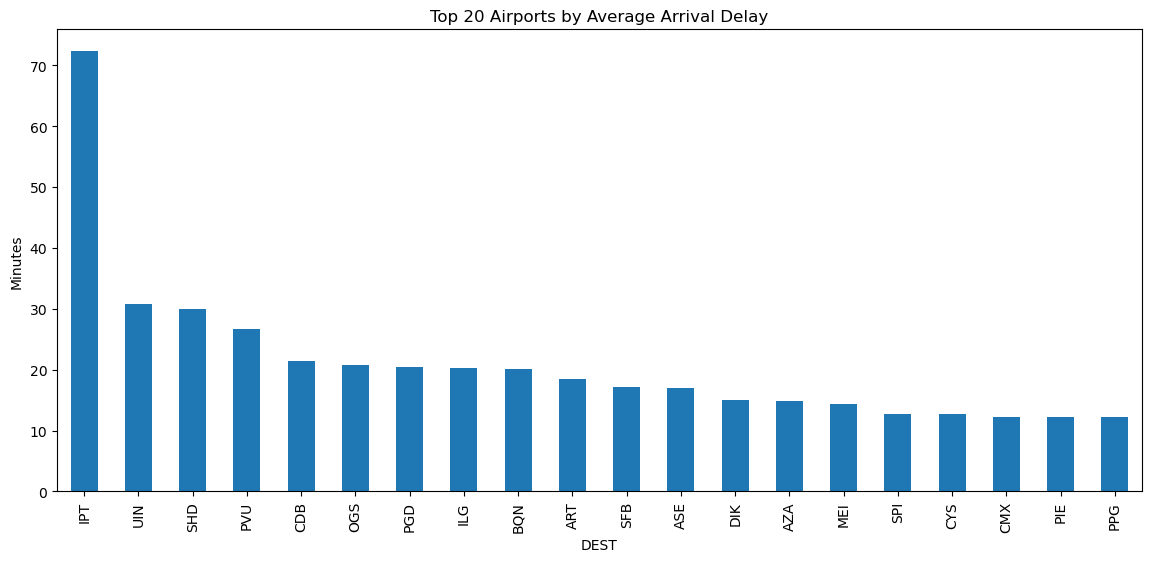

In [8]:
destination_delay = (
    df.groupby("DEST")["ARR_DELAY"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

destination_delay.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Top 20 Airports by Average Arrival Delay")
plt.ylabel("Minutes")

plt.show()

In [9]:
df["Month"] = df["FL_DATE"].dt.month_name()

In [10]:
monthly_delay = (
    df.groupby("Month")["ARR_DELAY"]
      .mean()
)

In [11]:
df["DayOfWeek"] = df["FL_DATE"].dt.day_name()

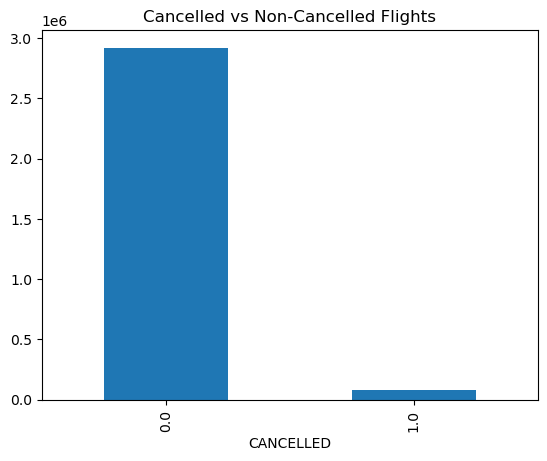

In [12]:
cancelled = df["CANCELLED"].value_counts()

cancelled.plot(
    kind="bar"
)

plt.title("Cancelled vs Non-Cancelled Flights")

plt.show()

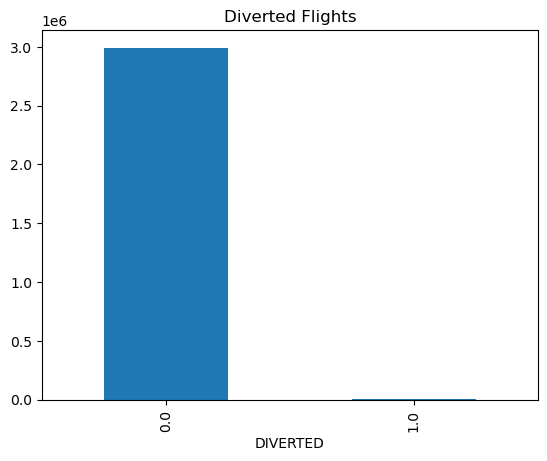

In [13]:
diverted = df["DIVERTED"].value_counts()

diverted.plot(
    kind="bar"
)

plt.title("Diverted Flights")

plt.show()

In [14]:
delay_causes = {
    "Carrier": df["DELAY_DUE_CARRIER"].sum(),
    "Weather": df["DELAY_DUE_WEATHER"].sum(),
    "NAS": df["DELAY_DUE_NAS"].sum(),
    "Security": df["DELAY_DUE_SECURITY"].sum(),
    "Late Aircraft": df["DELAY_DUE_LATE_AIRCRAFT"].sum()
}

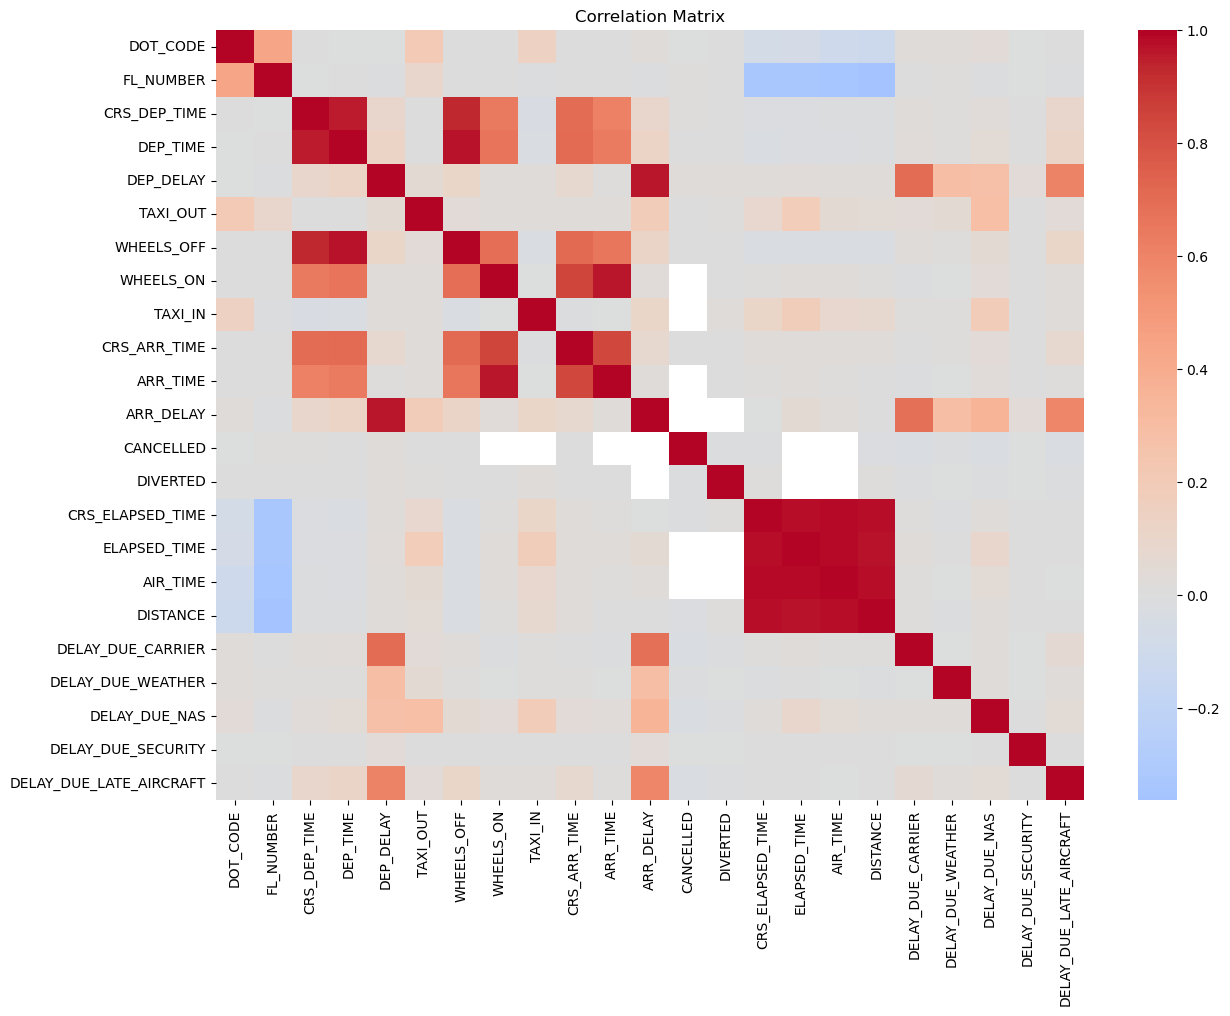

In [15]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

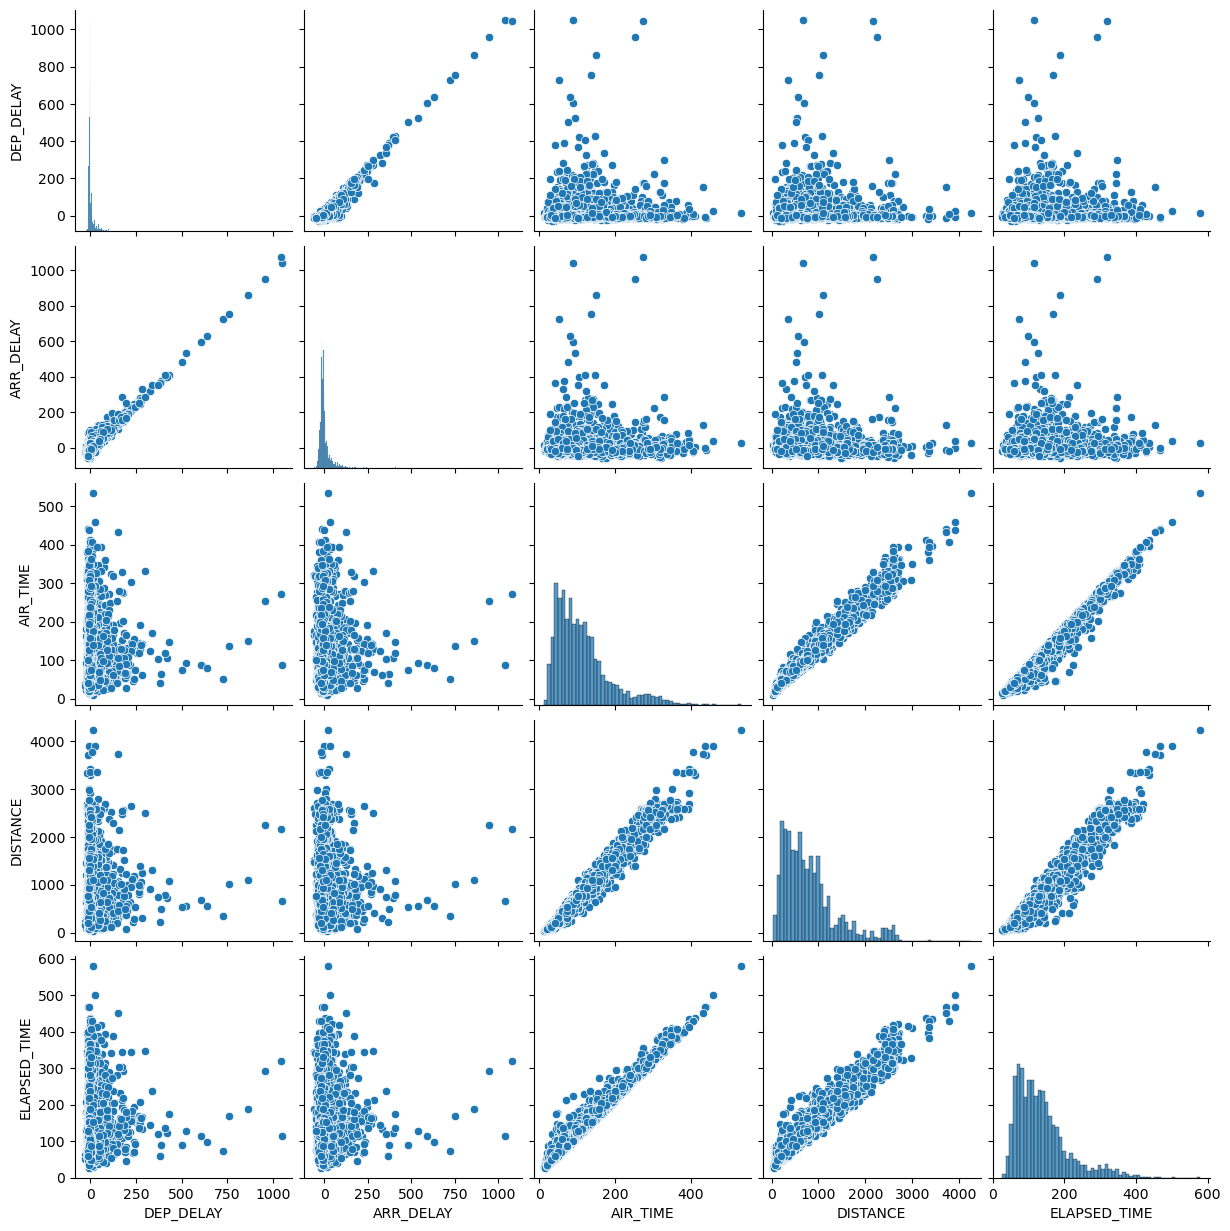

In [16]:
sample_df = df.sample(5000, random_state=42)

sns.pairplot(
    sample_df[
        [
            "DEP_DELAY",
            "ARR_DELAY",
            "AIR_TIME",
            "DISTANCE",
            "ELAPSED_TIME"
        ]
    ]
)

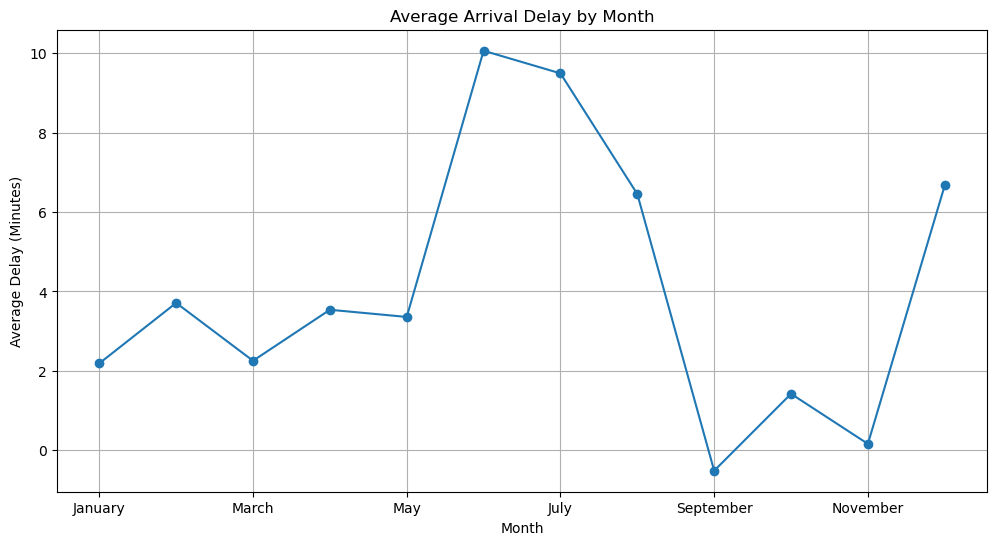

In [17]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_delay = (
    df.groupby("Month")["ARR_DELAY"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(12,6))

monthly_delay.plot(marker="o")

plt.title("Average Arrival Delay by Month")
plt.ylabel("Average Delay (Minutes)")
plt.xlabel("Month")

plt.grid(True)

plt.show()

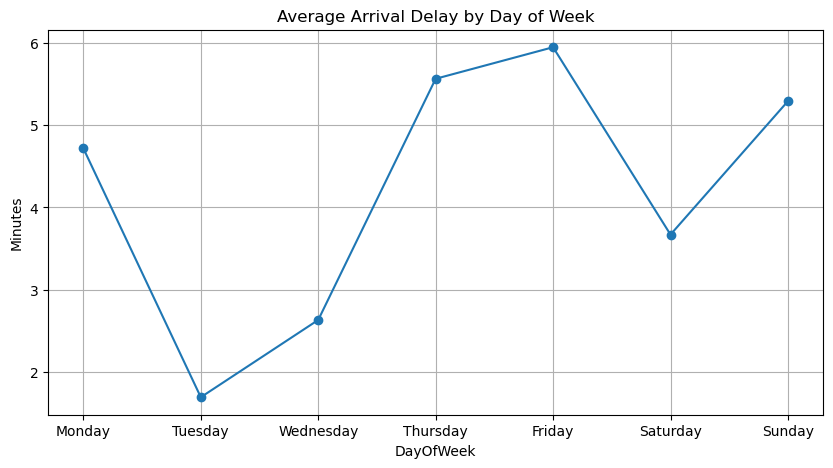

In [18]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_delay = (
    df.groupby("DayOfWeek")["ARR_DELAY"]
      .mean()
      .reindex(day_order)
)

plt.figure(figsize=(10,5))

daily_delay.plot(marker="o")

plt.title("Average Arrival Delay by Day of Week")

plt.ylabel("Minutes")

plt.grid(True)

plt.show()

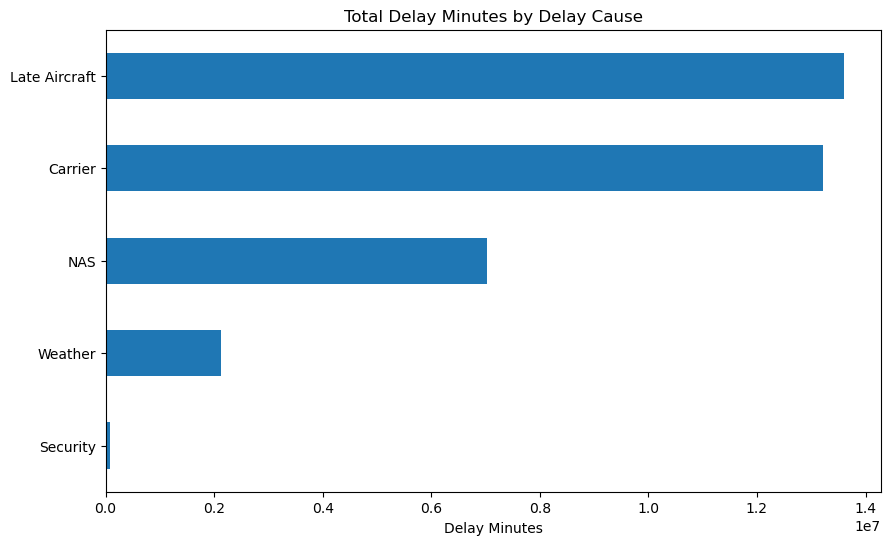

In [19]:
delay_causes = {
    "Carrier": df["DELAY_DUE_CARRIER"].sum(),
    "Weather": df["DELAY_DUE_WEATHER"].sum(),
    "NAS": df["DELAY_DUE_NAS"].sum(),
    "Security": df["DELAY_DUE_SECURITY"].sum(),
    "Late Aircraft": df["DELAY_DUE_LATE_AIRCRAFT"].sum()
}

delay_causes = pd.Series(delay_causes)

plt.figure(figsize=(10,6))

delay_causes.sort_values().plot(kind="barh")

plt.title("Total Delay Minutes by Delay Cause")

plt.xlabel("Delay Minutes")

plt.show()

In [20]:
cancel_percentage = (
    df["CANCELLED"]
    .value_counts(normalize=True)
    *100
)

print(cancel_percentage)

CANCELLED
0.0    97.362
1.0     2.638
Name: proportion, dtype: float64


In [21]:
diversion_percentage = (
    df["DIVERTED"]
    .value_counts(normalize=True)
    *100
)

print(diversion_percentage)

DIVERTED
0.0    99.7648
1.0     0.2352
Name: proportion, dtype: float64


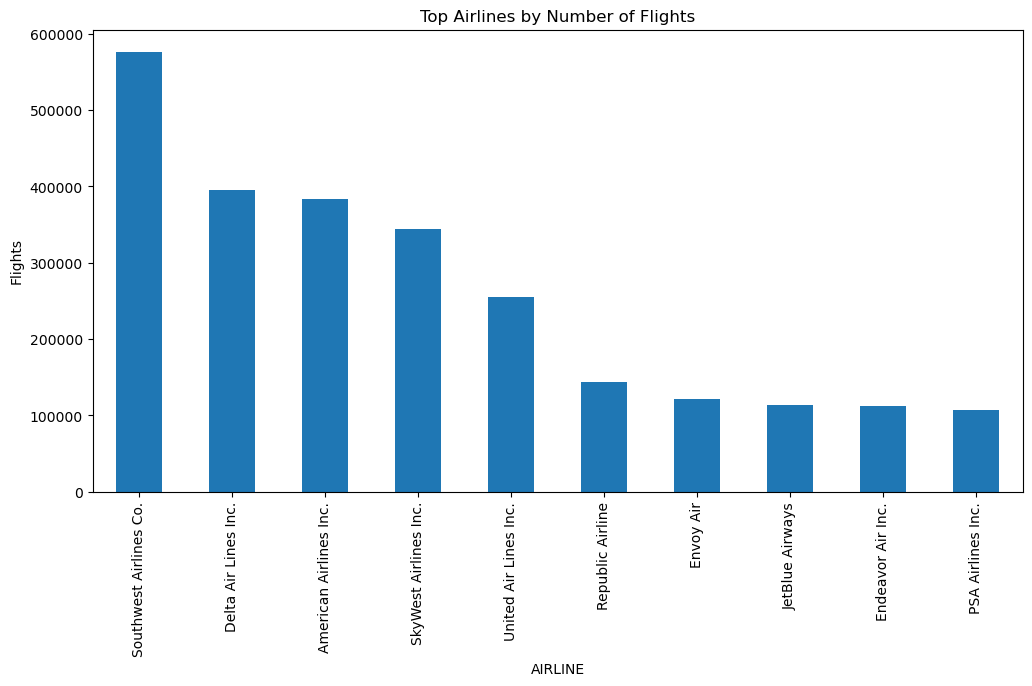

In [22]:
top_airlines = (
    df["AIRLINE"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_airlines.plot(kind="bar")

plt.title("Top Airlines by Number of Flights")

plt.ylabel("Flights")

plt.show()

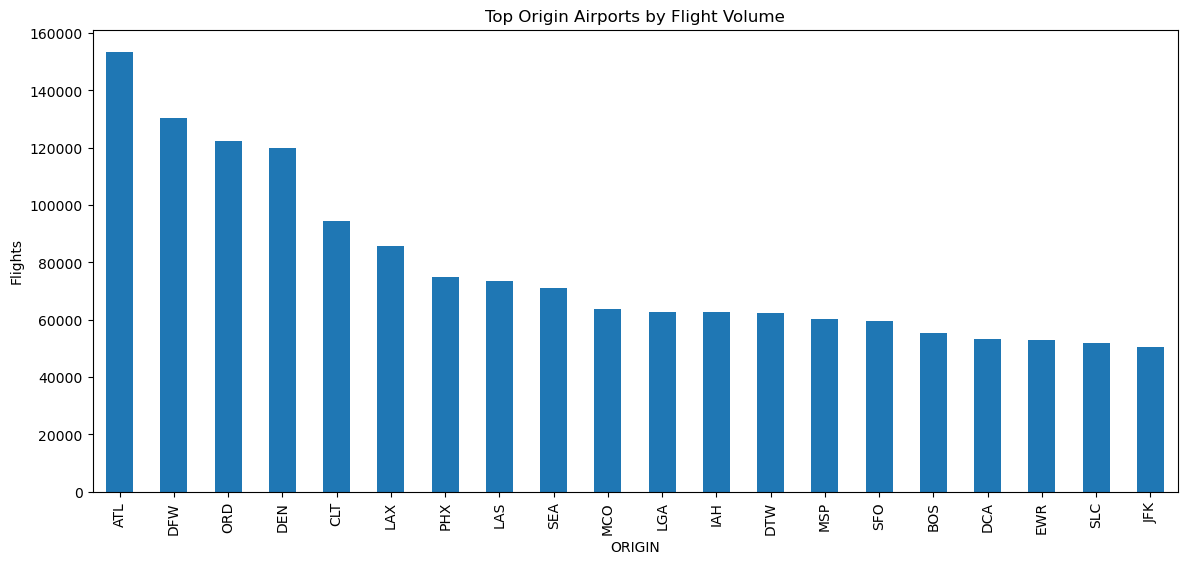

In [23]:
top_airports = (
    df["ORIGIN"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(14,6))

top_airports.plot(kind="bar")

plt.title("Top Origin Airports by Flight Volume")

plt.ylabel("Flights")

plt.show()

Operational Insights

The exploratory analysis reveals several important characteristics of airline operations within the dataset.

Most flights depart and arrive close to their scheduled times, although a small proportion experience substantial delays.
Delay distributions are positively skewed, indicating that extreme delays are relatively rare but operationally significant.
Airline performance varies considerably, with some carriers demonstrating consistently lower average delays than others.
Several airports exhibit significantly higher average delays, suggesting congestion or operational constraints.
Flight cancellations and diversions represent only a small proportion of all operations, indicating generally reliable airline operations.
Delay attribution analysis shows that carrier delays and late aircraft delays contribute most to total operational delay, while security-related delays have minimal impact.
Strong positive correlations between air time, elapsed time, and flight distance confirm expected operational relationships.
The dataset provides a robust foundation for subsequent feature engineering and AI-based operational risk assessment.